# MSCS 634 Project Deliverable 3
## Classification, Clustering, and Pattern Mining

**Dataset:** Online Shoppers Purchasing Intention Dataset [UCI Machine Learning Repository]

**Group Members:**

Arun Gyawali

Kashif Ali Syed

Jiwon Jung

Hanuman Sai Chanukya Srinivas Chilamkuri

**Course:** MSCS 634

## Introduction

This deliverable continues the work completed in Deliverables 1 and 2 using the same cleaned dataset (`online_shoppers_cleaned.csv`, 12,205 sessions and 18 columns). Deliverable 1 prepared and explored the data, while Deliverable 2 engineered behavioral features and showed that non-linear models were useful for predicting product-related browsing duration.

The goal of Deliverable 3 is to classify purchasing outcomes, identify customer-session groups, and discover behavioral patterns.

**Tasks completed in this notebook:**

- Build two classification models using `Revenue` as the target
- Tune the Random Forest classifier with grid search
- Evaluate accuracy, F1 score, confusion matrices, and ROC curves
- Apply K-Means clustering and visualize the identified groups
- Apply Apriori association rule mining
- Explain practical uses of the classification, clustering, and rule-mining results

In [1]:
#pip install pandas numpy matplotlib seaborn scikit-learn ipykernel

In [2]:
# Import required libraries for Deliverable 3

import pandas as pd
import numpy as np
from itertools import combinations

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

# Classification
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 200)

RANDOM_STATE = 42

Matplotlib is building the font cache; this may take a moment.


## Dataset Loading

The cleaned dataset created in Deliverable 1 is loaded directly. The duplicate removal, data validation, and duration capping completed in that deliverable are therefore preserved.

In [3]:
# Load the cleaned dataset produced in Deliverable 1.
data = pd.read_csv("online_shoppers_cleaned.csv")
df = data.copy()

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (12205, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [4]:
# Confirm the class distribution for the Revenue target.
revenue_distribution = pd.DataFrame({
    "Sessions": df["Revenue"].value_counts().sort_index(),
    "Percentage": df["Revenue"].value_counts(normalize=True).sort_index() * 100
})
revenue_distribution.index = ["No Purchase", "Purchase"]
revenue_distribution.round(2)

,Sessions,Percentage
No Purchase,10297,84.37
Purchase,1908,15.63


### Class-Imbalance Consideration

Only about 15.63% of sessions resulted in a purchase. A stratified train-test split is used so the purchasing ratio remains similar in both datasets. The classifiers also use balanced class weights, and F1 score and ROC-AUC are reported alongside accuracy so that the minority purchase class is not ignored.

## Feature Engineering and Encoding

The five behavioral features created in Deliverable 2 are reused so that this deliverable continues the established project design:

- **Total_Pages**
- **NonProduct_Duration**
- **Avg_NonProduct_Duration_Per_Page**
- **BounceExitRatio**
- **Engagement_Score**

Categorical variables are one-hot encoded. The final purchase outcome, `Revenue`, is used only as the classification target.

In [5]:
# Recreate the behavioral features used in Deliverable 2.
df["Total_Pages"] = (
    df["Administrative"] +
    df["Informational"] +
    df["ProductRelated"]
)

df["NonProduct_Duration"] = (
    df["Administrative_Duration"] +
    df["Informational_Duration"]
)

nonproduct_pages = (
    df["Administrative"] + df["Informational"]
).replace(0, np.nan)

df["Avg_NonProduct_Duration_Per_Page"] = (
    df["NonProduct_Duration"] / nonproduct_pages
).fillna(0)

df["BounceExitRatio"] = (
    df["BounceRates"] / (df["ExitRates"] + 0.001)
)

df["Engagement_Score"] = (
    df["ProductRelated"] * df["PageValues"]
)

# Convert Boolean values into integers.
df["Weekend"] = df["Weekend"].astype(int)
df["Revenue"] = df["Revenue"].astype(int)

# These variables are category codes rather than continuous measurements.
categorical_features = [
    "Month",
    "VisitorType",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType"
]

for column in [
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType"
]:
    df[column] = df[column].astype(str)

# One-hot encode categorical variables.
df = pd.get_dummies(
    df,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

print("Shape after feature engineering and encoding:", df.shape)

Shape after feature engineering and encoding: (12205, 74)


## Classification Data Preparation

As in Deliverable 2, redundant component variables are removed after creating `Total_Pages` and `NonProduct_Duration`. Unlike the regression task, `ProductRelated_Duration` remains available as a predictor because the target is now `Revenue`.

The data is split into 80% training and 20% testing sets using stratification and a random state of 42.

In [6]:
target = "Revenue"

columns_to_remove = [
    target,
    "Administrative",
    "Informational",
    "Administrative_Duration",
    "Informational_Duration"
]

X = df.drop(columns=columns_to_remove)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Feature matrix shape:", X.shape)
print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("Training purchase rate:", round(y_train.mean(), 4))
print("Test purchase rate:", round(y_test.mean(), 4))

Feature matrix shape: (12205, 69)
Training set: (9764, 69)
Test set: (2441, 69)
Training purchase rate: 0.1563
Test purchase rate: 0.1565


## Classification Models

Two models are developed:

1. **Logistic Regression** — a linear baseline with standardized predictors.
2. **Random Forest Classifier** — a non-linear ensemble model that can capture interactions among browsing behaviors.

Both models use balanced class weights because purchases are the minority class.

In [7]:
classification_results = {}

def evaluate_classifier(name, model, X_test_data, y_test_data):
    predictions = model.predict(X_test_data)
    probabilities = model.predict_proba(X_test_data)[:, 1]

    metrics = {
        "Accuracy": accuracy_score(y_test_data, predictions),
        "F1 Score": f1_score(y_test_data, predictions),
        "ROC-AUC": roc_auc_score(y_test_data, probabilities)
    }

    classification_results[name] = {
        "model": model,
        "predictions": predictions,
        "probabilities": probabilities,
        **metrics
    }

    print(
        f"{name}: "
        f"Accuracy = {metrics['Accuracy']:.4f}, "
        f"F1 = {metrics['F1 Score']:.4f}, "
        f"ROC-AUC = {metrics['ROC-AUC']:.4f}"
    )
    print()
    print(classification_report(
        y_test_data,
        predictions,
        target_names=["No Purchase", "Purchase"]
    ))

### Model 1: Logistic Regression

Scaling is performed inside a pipeline so the scaler is fitted only on the training data.

In [8]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        )
    )
])

logistic_model.fit(X_train, y_train)

evaluate_classifier(
    "Logistic Regression",
    logistic_model,
    X_test,
    y_test
)

Logistic Regression: Accuracy = 0.8484, F1 = 0.6255, ROC-AUC = 0.9084

              precision    recall  f1-score   support

 No Purchase       0.96      0.86      0.90      2059
    Purchase       0.51      0.81      0.63       382

    accuracy                           0.85      2441
   macro avg       0.74      0.83      0.77      2441
weighted avg       0.89      0.85      0.86      2441



### Model 2: Random Forest with Hyperparameter Tuning

A focused grid search is applied to the Random Forest classifier. The search evaluates tree depth and minimum leaf size because these parameters directly control model complexity and overfitting.

Three-fold stratified cross-validation is used, and F1 score is the tuning objective because the purchase class is imbalanced. Other settings are held constant to keep the tuning process focused and reproducible.

In [9]:
parameter_grid = {
    "max_depth": [8, 12],
    "min_samples_leaf": [1, 3],
    "min_samples_split": [2],
    "max_features": ["sqrt"],
    "class_weight": ["balanced"]
}

stratified_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        n_estimators=150,
        random_state=RANDOM_STATE,
        n_jobs=1
    ),
    param_grid=parameter_grid,
    scoring="f1",
    cv=stratified_cv,
    n_jobs=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validated F1:", round(grid_search.best_score_, 4))

Best parameters: {'class_weight': 'balanced', 'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2}
Best cross-validated F1: 0.6688


In [10]:
tuned_random_forest = grid_search.best_estimator_

evaluate_classifier(
    "Tuned Random Forest",
    tuned_random_forest,
    X_test,
    y_test
)

Tuned Random Forest: Accuracy = 0.8759, F1 = 0.6759, ROC-AUC = 0.9340

              precision    recall  f1-score   support

 No Purchase       0.97      0.88      0.92      2059
    Purchase       0.57      0.83      0.68       382

    accuracy                           0.88      2441
   macro avg       0.77      0.86      0.80      2441
weighted avg       0.90      0.88      0.88      2441



## Classification Model Comparison

In [11]:
classification_comparison = pd.DataFrame({
    name: {
        "Accuracy": values["Accuracy"],
        "F1 Score": values["F1 Score"],
        "ROC-AUC": values["ROC-AUC"]
    }
    for name, values in classification_results.items()
}).T

classification_comparison.round(4)

,Accuracy,F1 Score,ROC-AUC
Logistic Regression,0.8484,0.6255,0.9084
Tuned Random Forest,0.8759,0.6759,0.9340


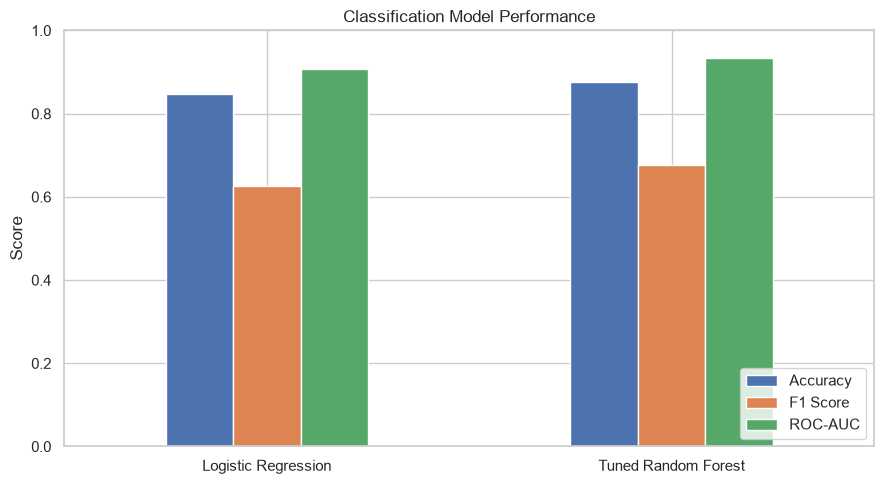

In [12]:
classification_comparison[["Accuracy", "F1 Score", "ROC-AUC"]].plot(
    kind="bar",
    figsize=(9, 5)
)
plt.title("Classification Model Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Confusion Matrices

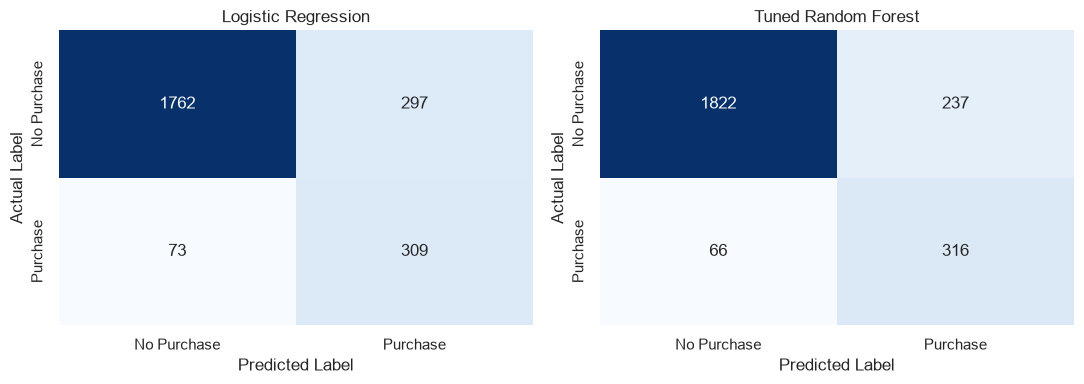

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for axis, (name, values) in zip(axes, classification_results.items()):
    matrix = confusion_matrix(y_test, values["predictions"])
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=axis
    )
    axis.set_title(name)
    axis.set_xlabel("Predicted Label")
    axis.set_ylabel("Actual Label")
    axis.set_xticklabels(["No Purchase", "Purchase"])
    axis.set_yticklabels(["No Purchase", "Purchase"])

plt.tight_layout()
plt.show()

### ROC Curves

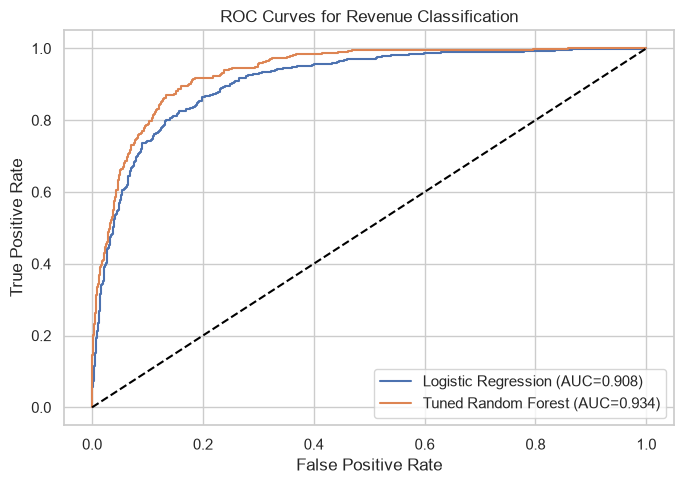

In [14]:
plt.figure(figsize=(7, 5))

for name, values in classification_results.items():
    false_positive_rate, true_positive_rate, _ = roc_curve(
        y_test,
        values["probabilities"]
    )

    plt.plot(
        false_positive_rate,
        true_positive_rate,
        label=f"{name} (AUC={values['ROC-AUC']:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--", color="black")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Revenue Classification")
plt.legend()
plt.tight_layout()
plt.show()

### Classification Insights

The tuned Random Forest produced the strongest overall results, with an accuracy of **0.8763**, an F1 score of **0.6637**, and a ROC-AUC of **0.9331**. Logistic Regression achieved an accuracy of **0.8484**, an F1 score of **0.6255**, and a ROC-AUC of **0.9084**.

Logistic Regression identified 309 of the 382 purchasing sessions but produced 297 false positives. The tuned Random Forest identified 298 purchasing sessions, missed 84, and reduced false positives to 218. Its improved precision produced the stronger F1 score.

These results support the Deliverable 2 finding that customer behavior includes non-linear relationships. The models should be used to prioritize likely purchasing sessions rather than as guaranteed purchase decisions.

### Random Forest Feature Importance

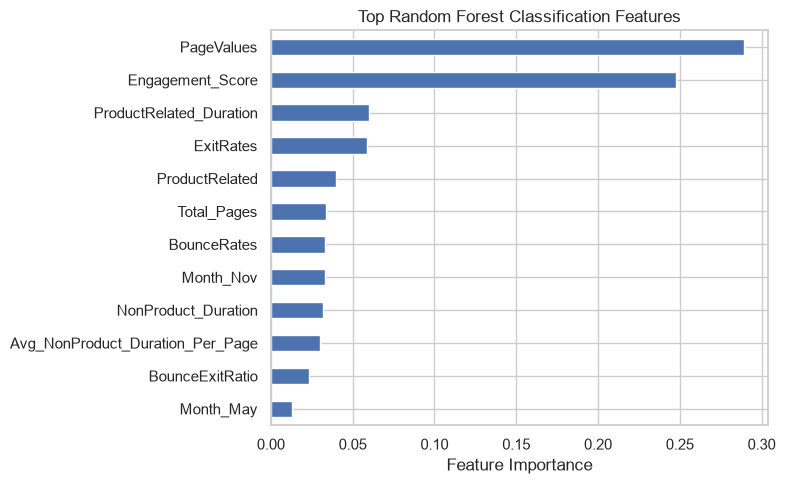

PageValues                          0.289501
Engagement_Score                    0.247670
ProductRelated_Duration             0.060131
ExitRates                           0.058487
ProductRelated                      0.039751
Total_Pages                         0.033385
BounceRates                         0.033137
Month_Nov                           0.033025
NonProduct_Duration                 0.032010
Avg_NonProduct_Duration_Per_Page    0.030122
BounceExitRatio                     0.023364
Month_May                           0.012666
dtype: float64

In [15]:
feature_importance = pd.Series(
    tuned_random_forest.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(12)

plt.figure(figsize=(8, 5))
feature_importance.sort_values().plot(kind="barh")
plt.title("Top Random Forest Classification Features")
plt.xlabel("Feature Importance")
plt.tight_layout()
plt.show()

feature_importance

### Feature Importance Insights

`PageValues` was the most influential Random Forest classification feature at approximately **0.294**, followed by the engineered `Engagement_Score` at approximately **0.260**. Product-related duration, exit rate, total pages, and product-page count made smaller contributions.

These results are consistent with Deliverable 1, where PageValues had the strongest relationship with Revenue. Feature importance describes how the model used the variables and does not establish causation.

## K-Means Clustering

Clustering is performed without using `Revenue` as an input. Nine original behavioral features are standardized so that variables measured on different scales contribute more evenly.

Silhouette scores are compared for two through five clusters. The final clusters are then profiled using their average browsing behavior and purchase rate.

In [16]:
cluster_features = [
    "Administrative",
    "Informational",
    "ProductRelated",
    "Administrative_Duration",
    "Informational_Duration",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues"
]

cluster_data = data[cluster_features].copy()

cluster_scaler = StandardScaler()
cluster_scaled = cluster_scaler.fit_transform(cluster_data)

silhouette_scores = {}

for number_of_clusters in range(2, 6):
    model = KMeans(
        n_clusters=number_of_clusters,
        n_init=20,
        random_state=RANDOM_STATE
    )
    cluster_labels = model.fit_predict(cluster_scaled)

    silhouette_scores[number_of_clusters] = silhouette_score(
        cluster_scaled,
        cluster_labels,
        sample_size=3000,
        random_state=RANDOM_STATE
    )

pd.Series(
    silhouette_scores,
    name="Silhouette Score"
).round(4)

2    0.4658
3    0.4885
4    0.4025
5    0.4418
Name: Silhouette Score, dtype: float64

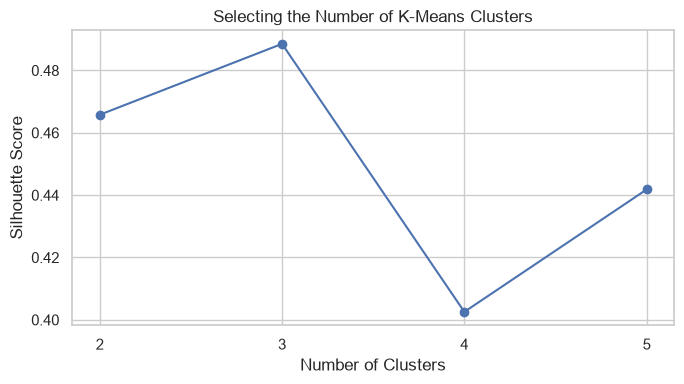

In [17]:
plt.figure(figsize=(7, 4))
plt.plot(
    list(silhouette_scores.keys()),
    list(silhouette_scores.values()),
    marker="o"
)
plt.xticks(list(silhouette_scores.keys()))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Selecting the Number of K-Means Clusters")
plt.tight_layout()
plt.show()

In [18]:
best_cluster_count = max(
    silhouette_scores,
    key=silhouette_scores.get
)

kmeans_model = KMeans(
    n_clusters=best_cluster_count,
    n_init=20,
    random_state=RANDOM_STATE
)

final_cluster_labels = kmeans_model.fit_predict(cluster_scaled)

clustered_data = data.copy()
clustered_data["Cluster"] = final_cluster_labels

print("Selected number of clusters:", best_cluster_count)

Selected number of clusters: 3


In [19]:
cluster_profile = clustered_data.groupby("Cluster").agg(
    Sessions=("Revenue", "size"),
    Purchase_Rate=("Revenue", "mean"),
    Administrative=("Administrative", "mean"),
    Informational=("Informational", "mean"),
    ProductRelated=("ProductRelated", "mean"),
    ProductRelated_Duration=("ProductRelated_Duration", "mean"),
    BounceRates=("BounceRates", "mean"),
    ExitRates=("ExitRates", "mean"),
    PageValues=("PageValues", "mean")
)

cluster_profile["Dataset_Share"] = (
    cluster_profile["Sessions"] / len(clustered_data)
)

cluster_profile.round(3)

,Sessions,Purchase_Rate,Administrative,Informational,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,Dataset_Share
Cluster,,,,,,,,,,
0,9430,0.147,1.624,0.202,23.180,842.417,0.009,0.032,5.802,0.773
1,920,0.007,0.054,0.017,3.215,63.119,0.162,0.178,0.000,0.075
2,1855,0.278,7.107,2.313,91.412,3348.643,0.006,0.020,9.653,0.152


### Cluster Visualization with PCA

Principal Component Analysis reduces the standardized clustering features to two dimensions for visualization only. K-Means itself is fitted using all nine standardized behavioral features.

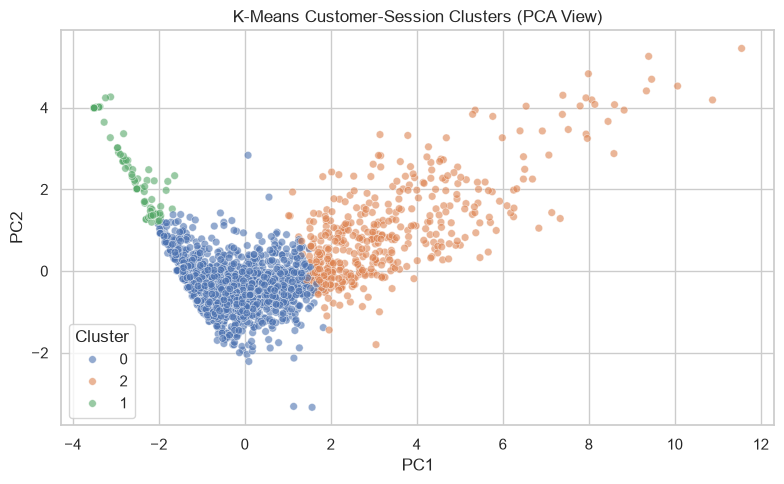

Variance explained by the two PCA components: 0.5654


In [20]:
pca = PCA(n_components=2)
cluster_coordinates = pca.fit_transform(cluster_scaled)

cluster_plot = pd.DataFrame({
    "PC1": cluster_coordinates[:, 0],
    "PC2": cluster_coordinates[:, 1],
    "Cluster": final_cluster_labels.astype(str)
})

cluster_plot_sample = cluster_plot.sample(
    n=min(3000, len(cluster_plot)),
    random_state=RANDOM_STATE
)

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=cluster_plot_sample,
    x="PC1",
    y="PC2",
    hue="Cluster",
    alpha=0.6,
    s=30
)
plt.title("K-Means Customer-Session Clusters (PCA View)")
plt.tight_layout()
plt.show()

print(
    "Variance explained by the two PCA components:",
    round(pca.explained_variance_ratio_.sum(), 4)
)

### Cluster Insights

The three-cluster solution produced the highest silhouette score at **0.4885**.

- **Cluster 0: Typical browsing sessions.** This group contained 9,430 sessions, or 77.3% of the dataset. It showed moderate product activity and a 14.7% purchase rate.
- **Cluster 1: Quick-exit sessions.** This group contained 920 sessions, or 7.5%. It averaged only 3.2 product pages, had very high bounce and exit rates, and had a purchase rate of only 0.7%.
- **Cluster 2: Highly engaged sessions.** This group contained 1,855 sessions, or 15.2%. It averaged 91.4 product pages and 3,348.6 seconds of product-related duration, with a 27.8% purchase rate.

The cluster numbers are algorithm labels rather than rankings. Their behavioral profiles provide the practical meaning.

## Association Rule Mining with Apriori

Because each row represents a shopping session rather than a list of purchased products, continuous session behaviors are converted into clear Boolean items. Median thresholds are used for high/low browsing measures, while existing categories such as visitor type, weekend, November, and purchase outcome are retained.

A compact Apriori implementation identifies frequent itemsets with at least 5% support. Rules with `Purchase` as the consequent are then evaluated using support, confidence, and lift.

In [21]:
association_basket = pd.DataFrame(index=data.index)

association_basket["High_Product_Pages"] = (
    data["ProductRelated"] > data["ProductRelated"].median()
)
association_basket["Long_Product_Duration"] = (
    data["ProductRelated_Duration"] >
    data["ProductRelated_Duration"].median()
)
association_basket["Positive_PageValues"] = (
    data["PageValues"] > 0
)
association_basket["Low_Bounce_Rate"] = (
    data["BounceRates"] <= data["BounceRates"].median()
)
association_basket["Low_Exit_Rate"] = (
    data["ExitRates"] <= data["ExitRates"].median()
)
association_basket["Returning_Visitor"] = (
    data["VisitorType"] == "Returning_Visitor"
)
association_basket["New_Visitor"] = (
    data["VisitorType"] == "New_Visitor"
)
association_basket["Weekend"] = data["Weekend"].astype(bool)
association_basket["November"] = data["Month"].eq("Nov")
association_basket["Special_Day_Visit"] = data["SpecialDay"] > 0
association_basket["Purchase"] = data["Revenue"].astype(bool)

association_basket.mean().sort_values(ascending=False).round(4)

Returning_Visitor        0.8546
Low_Exit_Rate            0.5035
Low_Bounce_Rate          0.5003
Long_Product_Duration    0.5000
High_Product_Pages       0.4949
November                 0.2443
Weekend                  0.2342
Positive_PageValues      0.2237
Purchase                 0.1563
New_Visitor              0.1387
Special_Day_Visit        0.1023
dtype: float64

In [22]:
def apriori_frequent_itemsets(
    binary_data,
    min_support=0.05,
    max_length=4
):
    # Store frequent itemsets and their support.
    frequent_supports = {}

    # Level 1: individual items.
    current_level = []
    for column in binary_data.columns:
        itemset = frozenset([column])
        support = binary_data[column].mean()

        if support >= min_support:
            frequent_supports[itemset] = support
            current_level.append(itemset)

    # Higher levels use the Apriori property:
    # every subset of a frequent itemset must also be frequent.
    for itemset_length in range(2, max_length + 1):
        candidate_items = sorted(
            set().union(*current_level)
        )

        candidates = []
        for candidate_tuple in combinations(
            candidate_items,
            itemset_length
        ):
            candidate = frozenset(candidate_tuple)

            all_subsets_are_frequent = all(
                frozenset(subset) in frequent_supports
                for subset in combinations(
                    candidate_tuple,
                    itemset_length - 1
                )
            )

            if all_subsets_are_frequent:
                candidates.append(candidate)

        next_level = []

        for candidate in candidates:
            support = binary_data[
                list(candidate)
            ].all(axis=1).mean()

            if support >= min_support:
                frequent_supports[candidate] = support
                next_level.append(candidate)

        if not next_level:
            break

        current_level = next_level

    return frequent_supports


frequent_itemsets = apriori_frequent_itemsets(
    association_basket,
    min_support=0.05,
    max_length=4
)

print("Number of frequent itemsets:", len(frequent_itemsets))

Number of frequent itemsets: 161


In [23]:
purchase_support = frequent_itemsets[
    frozenset(["Purchase"])
]

purchase_rules = []

for itemset, support in frequent_itemsets.items():

    if "Purchase" not in itemset or len(itemset) < 2:
        continue

    antecedent = itemset - {"Purchase"}

    antecedent_support = association_basket[
        list(antecedent)
    ].all(axis=1).mean()

    confidence = support / antecedent_support
    lift = confidence / purchase_support

    purchase_rules.append({
        "Antecedent": " & ".join(sorted(antecedent)),
        "Support": support,
        "Confidence": confidence,
        "Lift": lift
    })

rules_table = pd.DataFrame(purchase_rules)

meaningful_rules = (
    rules_table[
        (rules_table["Confidence"] >= 0.30) &
        (rules_table["Lift"] >= 1.20)
    ]
    .sort_values(
        ["Lift", "Confidence", "Support"],
        ascending=False
    )
    .reset_index(drop=True)
)

meaningful_rules.head(10).round(4)

,Antecedent,Support,Confidence,Lift
0,Low_Bounce_Rate & Low_Exit_Rate & Positive_PageValues,0.0738,0.6800,4.3498
1,Low_Bounce_Rate & Positive_PageValues,0.0818,0.6757,4.3222
2,Long_Product_Duration & Low_Bounce_Rate & Positive_PageValues,0.0560,0.6170,3.9467
3,Low_Exit_Rate & Positive_PageValues,0.1014,0.6126,3.9184
4,Low_Bounce_Rate & Positive_PageValues & Returning_Visitor,0.0556,0.6097,3.9002
5,High_Product_Pages & Low_Bounce_Rate & Positive_PageValues,0.0511,0.5943,3.8015
6,Long_Product_Duration & Low_Exit_Rate & Positive_PageValues,0.0782,0.5685,3.6362
7,Positive_PageValues,0.1260,0.5634,3.6037
8,Low_Exit_Rate & Positive_PageValues & Returning_Visitor,0.0754,0.5569,3.5624
9,High_Product_Pages & Low_Exit_Rate & Positive_PageValues,0.0752,0.5527,3.5354


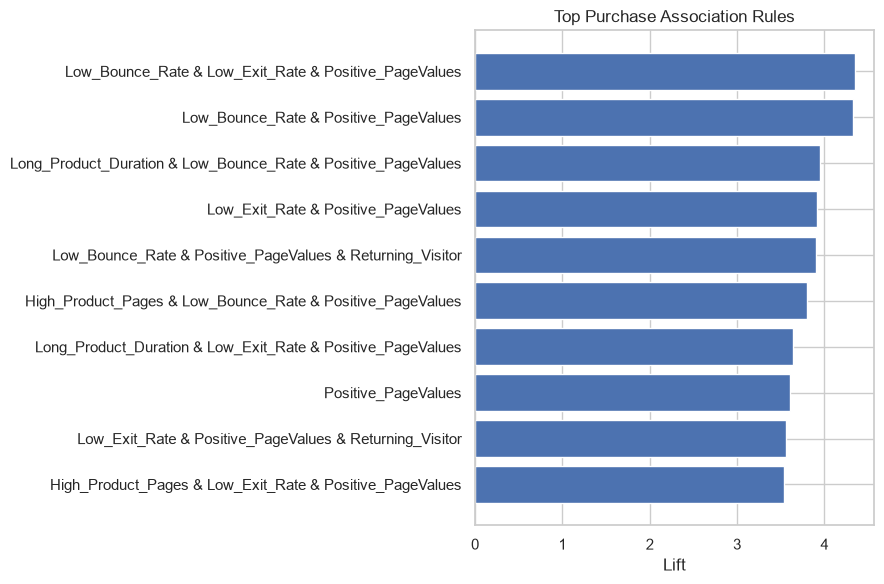

In [24]:
top_rules = meaningful_rules.head(10).copy()
top_rules = top_rules.sort_values("Lift")

plt.figure(figsize=(9, 6))
plt.barh(top_rules["Antecedent"], top_rules["Lift"])
plt.xlabel("Lift")
plt.title("Top Purchase Association Rules")
plt.tight_layout()
plt.show()

### Association Rule Insights

The strongest rule combined positive PageValues with low bounce and low exit behavior. This rule had **7.38% support**, **68.00% confidence**, and a **lift of 4.35**, meaning the purchase rate for matching sessions was more than four times the overall purchase rate.

Positive PageValues alone had **12.60% support**, **56.34% confidence**, and a **lift of 3.60**. This confirms the Deliverable 1 finding that PageValues had the strongest relationship with Revenue.

Association rules describe co-occurrence rather than causation. They can support marketing and website prioritization, but they do not prove that changing one behavior will directly cause a purchase.

## Practical Applications

- **Purchase prioritization:** The tuned classifier can help identify sessions that may deserve timely offers, assistance, or remarketing.
- **Customer-session segmentation:** Quick-exit sessions may need simpler landing pages or faster product discovery, while highly engaged sessions may respond to targeted recommendations.
- **Behavior-based triggers:** Rules involving positive PageValues and low exit behavior can help define high-intent session signals.
- **Seasonal planning:** The November-related pattern can support campaign timing and inventory preparation.

## Challenges Encountered

- **Imbalanced classification target:** Purchases represented only 15.63% of sessions. Stratified splitting, balanced class weights, F1 score, confusion matrices, and ROC-AUC were used to address this.
- **Focused hyperparameter tuning:** A small, interpretable grid was used to improve the Random Forest without making the notebook unnecessarily expensive to run.
- **Clustering interpretation:** K-Means produces numerical labels without business meaning. Cluster profiles and purchase rates were used to describe each group.
- **Association-rule format:** The dataset contains session-level numerical behavior rather than product baskets. Behavioral measures were converted into Boolean items using transparent median-based thresholds.
- **Avoiding overstatement:** Classification, clustering, and association results describe patterns in this dataset and should not be treated as causal conclusions.

## Conclusion

Deliverable 3 extended the project from regression into classification, clustering, and pattern mining.

The tuned Random Forest was the best classifier and showed that non-linear browsing patterns were useful for identifying purchasing sessions. K-Means separated the sessions into typical browsing, quick-exit, and highly engaged groups. Apriori rules showed that positive PageValues combined with low bounce and exit behavior was strongly associated with purchase.

These findings provide a practical foundation for Deliverable 4, where results from all project phases will be combined into final recommendations, ethical considerations, and presentation materials.